# Corner Plot

In [2]:

import os
os.environ["OMP_NUM_THREADS"] = "1"     # agama
os.environ["MKL_NUM_THREADS"] = "1"     # numpy, scipy
os.environ["OPENBLAS_NUM_THREADS"] = "1"    # numpy
os.environ["NUMEXPR_NUM_THREADS"] = "1"     # pandas

import torch 
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt
from galaxy_generation import transform_params
from object_handler import load_csv
import corner

In [9]:
# cored_params = load_csv("./model_8/3d/mass_density_samples_core_poco.csv", "ndarray")
# cusp_params = load_csv("./model_8/3d/mass_density_samples_core_poco.csv", "ndarray")
# cored_params = load_csv("./model_8/mock_noSF/MockA_samples_poco.csv", "ndarray")
cusp_params = load_csv("./model_8/mock/MockC_samples_fixed.csv", "ndarray")
log_rs = cusp_params[:, 4]
rstar_div_rs = cusp_params[:, 5]
ra_div_rstar = cusp_params[:, 6]
rstar = log_rs + rstar_div_rs
ra = ra_div_rstar + rstar

cusp_params[:, 5] = rstar
cusp_params[:, 6] = ra



## All Params

Text(0.5, 1.02, 'Galaxy B, no SF, fixed r*')

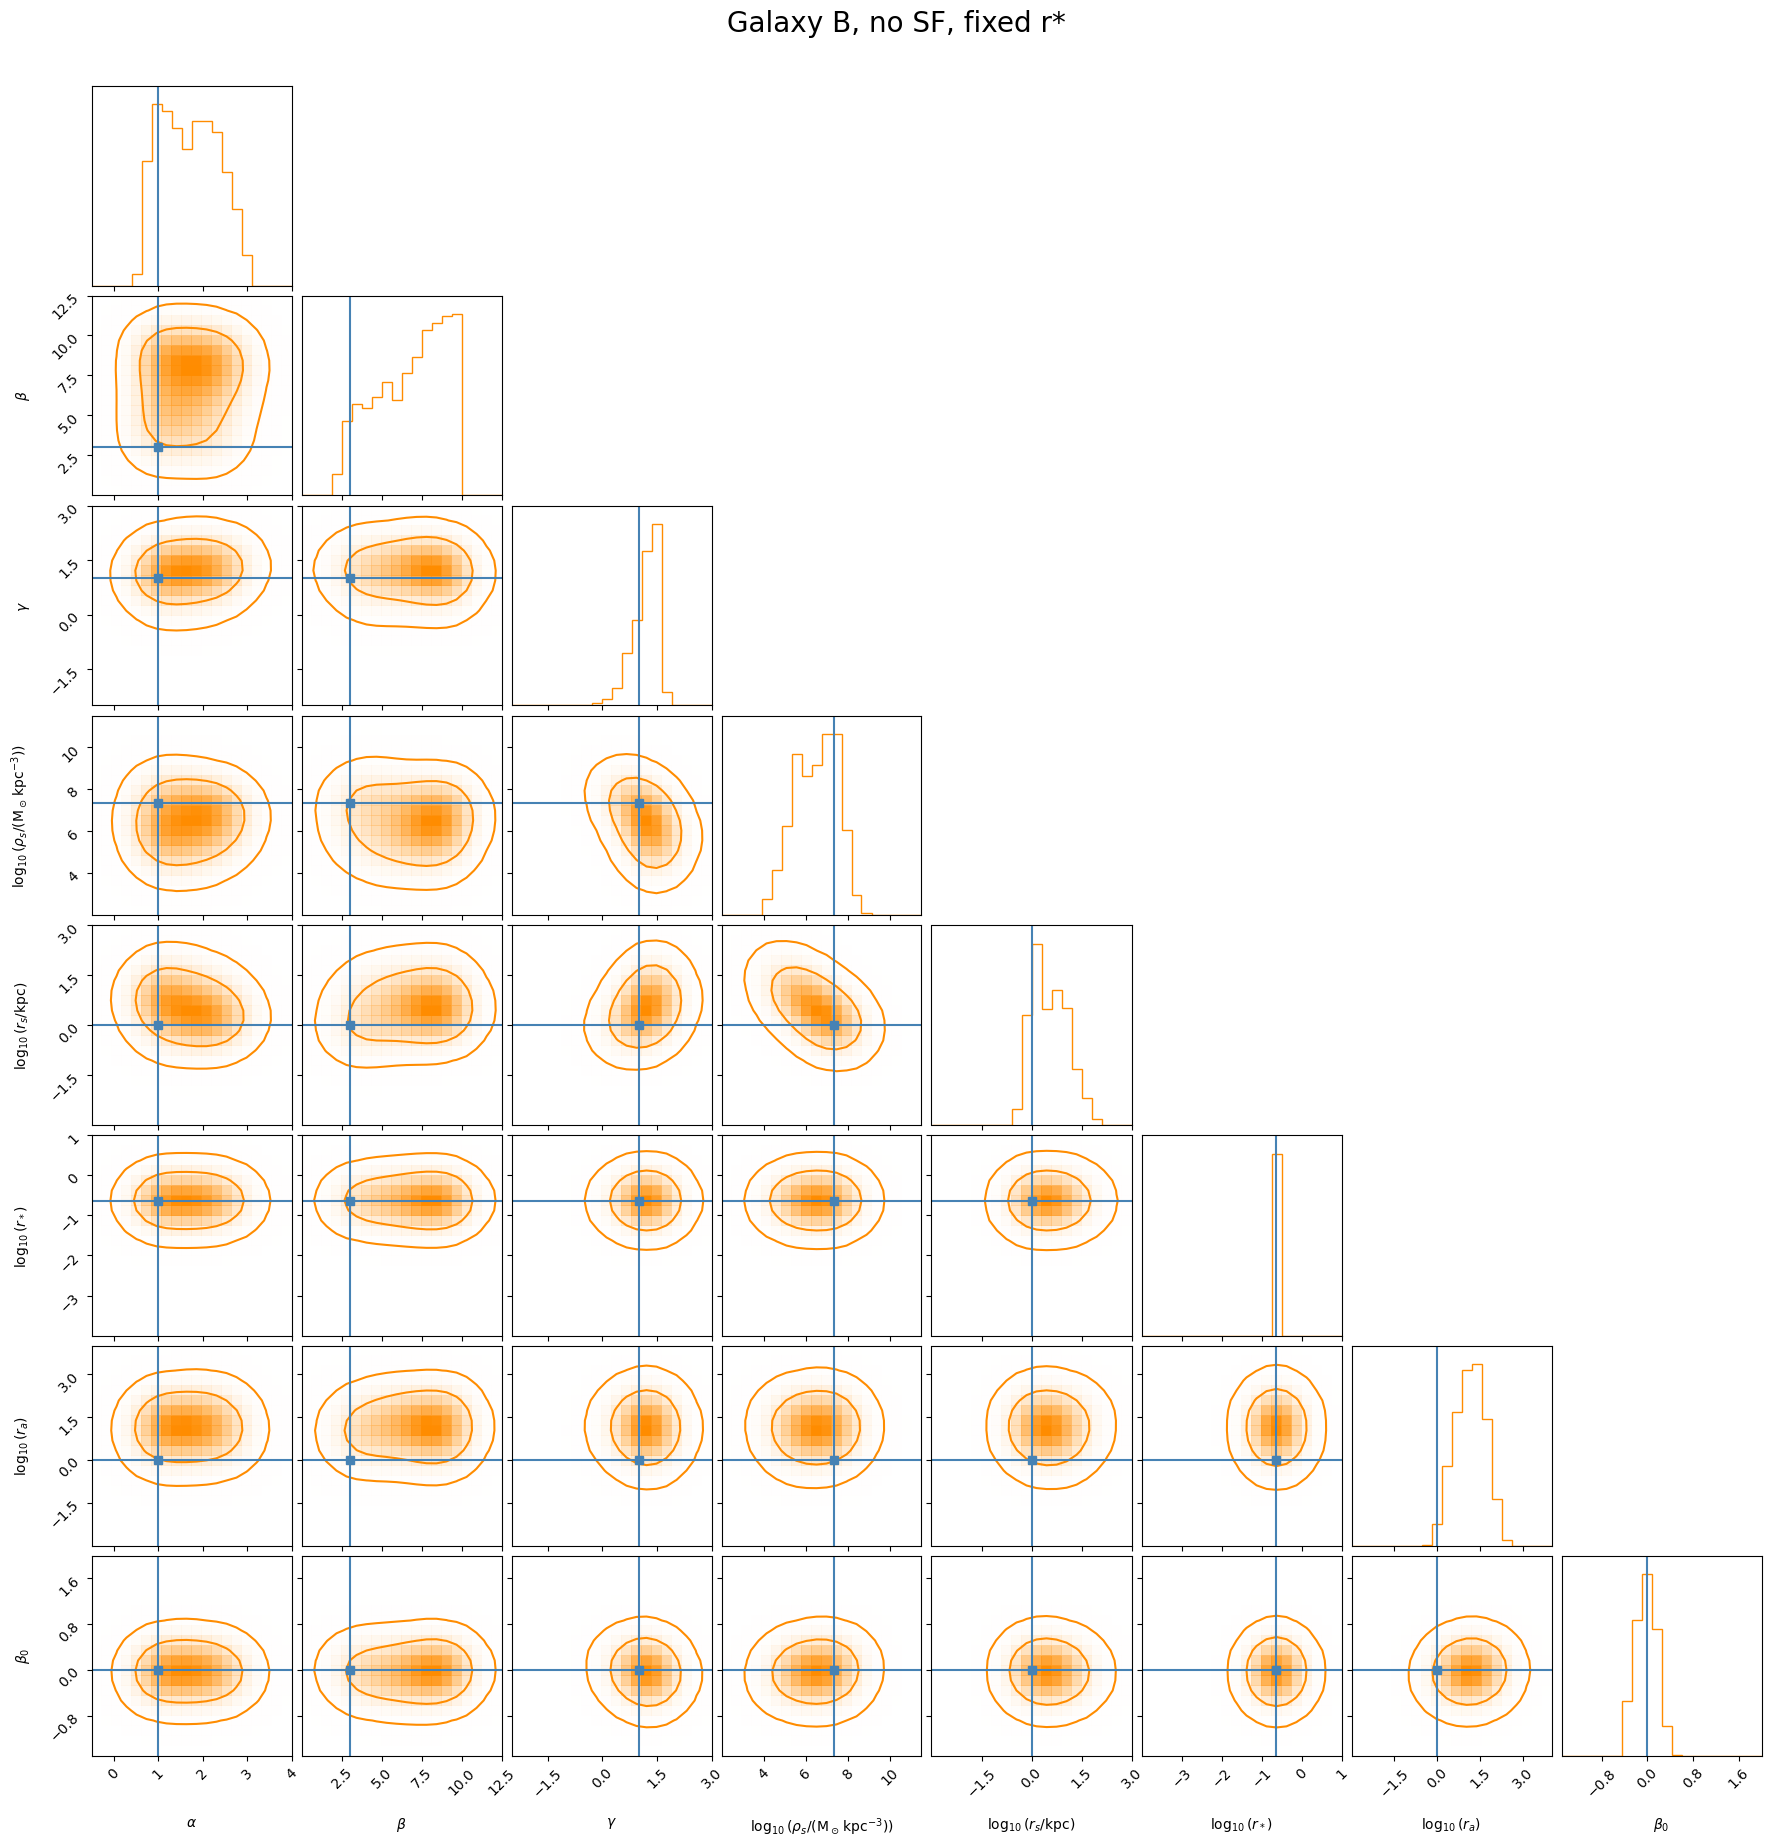

In [10]:
labels = [
    r"$\alpha$",
    r"$\beta$",
    r"$\gamma$",
    r"$\log_{10}(\rho_s / (\mathrm{M}_\odot\,\mathrm{kpc}^{-3}))$",
    r"$\log_{10}(r_s / \mathrm{kpc})$",
    r"$\log_{10}(r_* )$",
    r"$\log_{10}(r_a )$",
    r"$\beta_0$"
]
ranges = [
    [-0.5, 4.0],   # alpha              --> (0.5 - 1, 3.0 + 1)
    [0.0, 12.5],   # beta               --> (1.0 - 1, 10.0 + 1)
    [-2.5, 3.0],   # gamma              --> (-1.0 - 1, 2.0 + 1)
    [2.0, 11.5],   # log_rho_s          --> (3.0 - 1, 10.0 + 1)
    [-3.0, 3.0],   # log_r_s            --> (-2.0 - 1, 2.0 + 1)
    [-4.0, 1.0],   # log_r_star_over_r_s --> (-3.0 - 1, 0.0 + 1)
    [-3.0, 4.0],   # log_r_a_over_r_star --> (-1.0 - 1, 3.0 + 1)
    [-1.5, 2.0]    # beta0              --> (-0.5 - 1, 1.0 + 1)
]
fig = corner.corner(
    cusp_params,
    labels=labels,
    range=ranges,
    color="darkorange",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    plot_density=True,
    no_fill_contours=True,
    levels=(0.68, 0.95), # Confidence intervals to plot
    truths=[1, 3, 1, np.log10(2.33e7), 0, np.log10(0.229), 0.0, 0],
    # bins=30,
    smooth=2,
    # smooth1d=1.0,
)
fig.suptitle("Galaxy B, no SF, fixed r*", fontsize=20, y=1.02)

## 3 Params

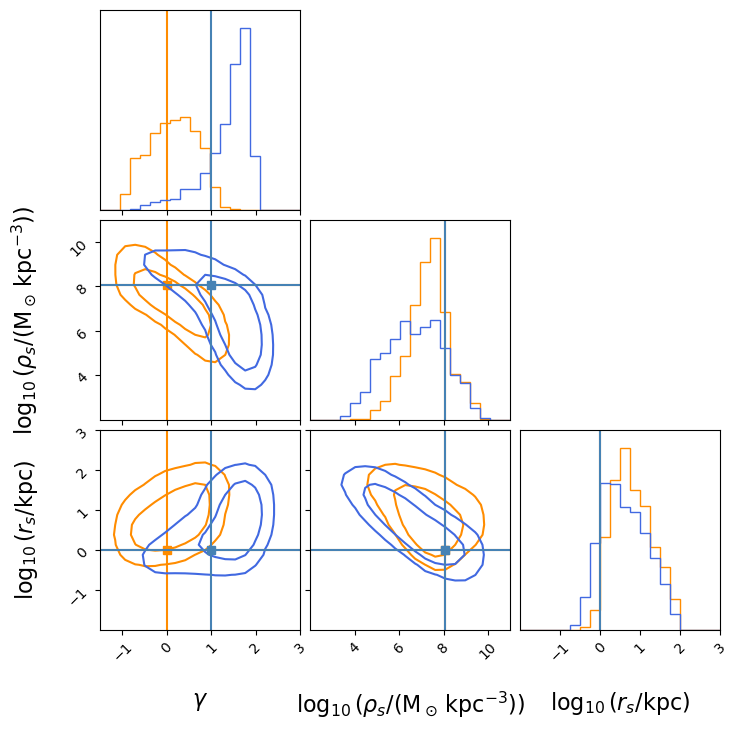

In [9]:
# --- Your Labels & Styling ---
labels = [
    r"$\gamma$",
    r"$\log_{10}(\rho_s / (\mathrm{M}_\odot\,\mathrm{kpc}^{-3}))$",
    r"$\log_{10}(r_s / \mathrm{kpc})$",
]
label_kwargs = {
    "fontsize": 16, 
    "fontweight": "bold"
}

shared_ranges = [[-1.5, 3], [2, 11], [-2, 3]]

# --- 1. FIRST DATASET (Core params - Orange) ---
fig = corner.corner(
    cored_params[:, (2, 3, 4)],
    labels=labels,
    label_kwargs=label_kwargs, 
    color="darkorange",
    range=shared_ranges, 
    hist_kwargs={"density": True},
    plot_datapoints=False,
    plot_density=False,
    no_fill_contours=True,
    levels=[0.68, 0.95], 
    smooth=1,
    
    # Truth parameters for Dataset 1
    truths=[0, 8.0755, 0],
    truth_color="darkorange",  # Forces the orange truth lines to match the contours
)

# --- 2. SECOND DATASET (Cusp params - Royal Blue) ---
fig = corner.corner(
    cusp_params[:, (2, 3, 4)],      
    fig=fig,                         
    color="royalblue",               
    range=shared_ranges,             
    hist_kwargs={"density": True},   
    plot_datapoints=False,
    plot_density=False,
    no_fill_contours=True,
    levels=[0.68, 0.95],
    smooth=1,
    # truths=[1, 7.3674, 0],
    truths=[1, 8.0755, 0],
    # (Notice: truths argument is removed from here)
)

# --- 3. OVERPLOT TRUTHS FOR SECOND DATASET (Royal Blue) ---
# This draws the vertical/horizontal lines for the second set of truths
# corner.overplot_lines(fig, [0, 8.0755, 0], color="royalblue", linestyle="--")

# plt.savefig(
#     "./model_8/mock_noSF/corner_poco.png", 
#     dpi=300, 
#     transparent=True, 
#     bbox_inches="tight"
# )